## Get started
This tutorial will show you how asynctorch can be used with the mixed architecture. Make sure asynctorch, snnTorch and tonic have been installed! Tonic is not an automatic dependency of asynctorch because it is not required for all use cases. For CUDA support, make sure you have a working CUDA installation and the correct version of PyTorch installed.

### Import packages

In [1]:
import torch
import tonic
import matplotlib.pyplot as plt
import tonic.transforms as transforms
from asynctorch.simulator.async_simulator import AsyncSimulator
from asynctorch.nn.architecture.mixed_architecture import MixedArchitecture, AsyncNetwork, AsyncLayer
from asynctorch.nn.neuron.lif_state import LIFState
from asynctorch.simulator.extensions.spike_dropout_extension import SpikeDropoutExtension
from asynctorch.simulator.spike_scheduler import RandomSpikeScheduler
from asynctorch.simulator.spike_selector import SpikeSelector
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.nn as nn
import snntorch.functional as SF
from asynctorch.utils.surrogate import Atan
from math import prod
import statistics
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

/home/roel/asynctorch/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


### Load data

In [2]:
timestep_size = 10000
transform = transforms.ToFrame(sensor_size=tonic.datasets.NMNIST.sensor_size, time_window=timestep_size)
train_dataset = tonic.datasets.NMNIST(save_to="./data", transform=transform, train=True, first_saccade_only=True)
collate_fn = tonic.collation.PadTensors(batch_first=False)

### Define the network and parameters for simulator
Run CNN or Linear (or adapt yourself), then "Build".
Spike dropout will be used for regularization. This is not directly included in the architecture, but rather added as an extension.

#### CNN

In [3]:
n_outputs = 10
input_shape = (2, 34, 34)
layer1_shape = (8, 16, 16)
layer2_shape = (16, 8, 8)
layer3_shape = (32, 4, 4)
module_per_layer = [nn.Conv2d(2, 8, kernel_size=3, stride=2, padding=0).to(device), 
                    nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1).to(device), 
                    nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1).to(device),
                    nn.Linear(prod(layer3_shape), n_outputs).to(device)]
shape_per_layer = [input_shape, layer1_shape, layer2_shape, (prod(layer3_shape), ), (n_outputs, )]
neurons_per_layer = [prod(layer1_shape), prod(layer2_shape), prod(layer3_shape), n_outputs]
n_neurons = sum(neurons_per_layer)

#### Linear

In [4]:
n_outputs = 10
input_shape = (2, 34, 34)
layer1_shape = (64, )
layer2_shape = (64, )
layer3_shape = (64, )
module_per_layer = [nn.Linear(prod(input_shape), prod(layer1_shape)).to(device),
                    nn.Linear(prod(layer1_shape), prod(layer2_shape)).to(device),
                    nn.Linear(prod(layer2_shape), prod(layer3_shape)).to(device),
                    nn.Linear(prod(layer3_shape), n_outputs).to(device)]
shape_per_layer = [(prod(input_shape), ), layer1_shape, layer2_shape, layer3_shape, (n_outputs, )]
neurons_per_layer = [prod(layer1_shape), prod(layer2_shape), prod(layer3_shape), n_outputs]
n_neurons = sum(neurons_per_layer)

#### Build

In [5]:
for module in module_per_layer:
    if hasattr(module, 'weight'):
        nn.init.xavier_uniform_(module.weight)
        
# Network architecture
async_network = AsyncNetwork.build_sequential(module_per_layer, shape_per_layer)
print(async_network)
print('Number of neurons:', n_neurons)
print('Number of parameters:', sum(p.numel() for p in async_network.parameters() if p.requires_grad))
network_module = MixedArchitecture(async_network, device)
input_dropout = SpikeDropoutExtension(p=0.25, apply_to_input=True, apply_to_network=False)

# Neuron model
spike_grad = Atan()
state_module = LIFState(
    neurons_per_layer,
    tau_m=1000,
    membrane_threshold=0.3,
    sync_threshold=0.0,
    spike_grad=spike_grad,
    sync_grad=spike_grad,
    device=device,
    refrac_dropout=0.8
)

# Simulator
spike_scheduler = RandomSpikeScheduler(state_module)
spike_selector_module = SpikeSelector(
    network_module,
    spike_scheduler,
    forward_group_size=8,
    device=device,
    prioritize_input=True,
)

AsyncNetwork(
  (input_layer): AsyncLayer(
    (module): Linear(in_features=2312, out_features=64, bias=True)
  )
  (layers): ModuleList(
    (0-1): 2 x AsyncLayer(
      (module): Linear(in_features=64, out_features=64, bias=True)
    )
    (2): AsyncLayer(
      (module): Linear(in_features=64, out_features=10, bias=True)
    )
  )
)
Number of neurons: 202
Number of parameters: 157002


## Start training
For training, we use the standard PyTorch training loop with some snnTorch specific functions. Instead of calling a forward pass on the network, we call the forward function of the simulator. This function takes the input data and the time step, and returns the output spikes of the network. The output spikes can then be used to calculate the loss and update the weights of the network.

In [6]:
async_simulator = AsyncSimulator(state_module, spike_selector_module, forward_step_extensions=[input_dropout])
#async_simulator.load_state_dict(torch.load('nmnist_mixed_asynctorch.pt'))
train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True, collate_fn=collate_fn)
async_simulator.train()
n_epochs = 1
optimizer = torch.optim.Adam(async_simulator.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = SF.ce_rate_loss()
accuracy_function = SF.accuracy_rate

losses = []
accuracies = []
for epoch in range(n_epochs):
    batch_iter = iter(train_dataloader)
    for data, targets in tqdm(batch_iter):
        data = data.to(device)
        targets = targets.to(device)
        async_simulator.reset_state()

        # Forward pass
        ys = []
        for t in range(data.shape[0]):
            ts_data = data[t].view(data[t].shape[0], -1)
            spk_out = async_simulator(ts_data, dt=timestep_size)[:, n_neurons-n_outputs:]
            ys.append(spk_out) 
        y = torch.stack(ys)
        loss = loss_fn(y, targets)
        losses.append(loss.item())
        accuracy = accuracy_function(y, targets)
        accuracies.append(accuracy)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        #break
        


100%|██████████| 235/235 [00:56<00:00,  4.17it/s]


### Check training progress

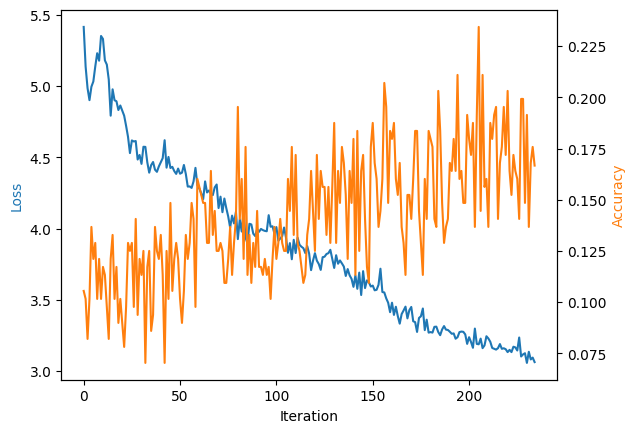

Accuracy:  0.14213209219858156


In [7]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.plot(losses, color='C0')
ax2.plot(accuracies, color='C1')

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss', color='C0')
ax2.set_ylabel('Accuracy', color='C1')

plt.show()
print("Accuracy: ", statistics.mean(accuracies))

### Export the trained model
The trained weights are kept in the simulator. We can use the standard PyTorch functions to save the weights of the network.

In [ ]:
torch.save(async_simulator.state_dict(), "./nmnist_mixed_asynctorch.pt")

FPTT (backup), saves about 70% memory, but less accurate.

In [ ]:
async_simulator = AsyncSimulator(state_module, spike_selector_module, forward_step_extensions=[input_dropout])
train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True, collate_fn=collate_fn)
async_simulator.train()
n_epochs = 1
optimizer = torch.optim.Adam(async_simulator.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = SF.ce_rate_loss()
accuracy_function = SF.accuracy_rate

losses = []
accuracies = []

for epoch in range(n_epochs):
    for data, targets in tqdm(train_dataloader):
        data = data.to(device)
        targets = targets.to(device)
        async_simulator.reset_state()

        # Forward pass with FPTT
        optimizer.zero_grad()  # Zero gradients at the start of each sequence
        ys = []
        for t in range(data.shape[0]):  # Iterate over timesteps
            ts_data = data[t].view(data[t].shape[0], -1)  # Reshape the data for the current timestep
            spk_out = async_simulator(ts_data, dt=timestep_size)[:, n_neurons-n_outputs:]  # Forward step
            ys.append(spk_out)

            # Compute loss and update weights for each time step
            y = torch.stack(ys)  # Stack outputs for the current timestep
            loss = loss_fn(y, targets)
            loss.backward()  # Compute gradients for this timestep
            optimizer.step()  # Update weights based on the gradients
            optimizer.zero_grad()
            
            losses.append(loss.item())
            accuracy = accuracy_function(y, targets)
            accuracies.append(accuracy)
            ys[-1] = ys[-1].detach()
            async_simulator.detach_state()

        # After processing all timesteps, compute overall accuracy and loss
        final_loss = loss_fn(torch.stack(ys), targets)
        losses.append(final_loss.item())
        final_accuracy = accuracy_function(torch.stack(ys), targets)
        accuracies.append(final_accuracy)